# Yield-curve inversion

Separate a negative term spread from a recession forecast.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

An inversion is a statement about the ordering of yields across maturities. A 10Y minus 2Y spread below zero says the selected long rate is below the selected short rate; it does not identify why that shape arose or forecast the date of a recession on its own.

This chapter calculates the spread from the constructed curve in two ways: directly from 10Y and 2Y OIS par quotes, and from the bootstrapped continuously compounded zero rates. It then applies a parallel shift and opposite steepener/flattener shocks to the zero-rate nodes. Reporting the object being shocked avoids mixing a par-quote spread with a zero-rate spread.

The spread is $10^4[z(10)-z(2)]$ basis points. A parallel shift cancels exactly. A shape shock changes the spread according to the difference between the long- and short-node shocks. This simple identity is checked in the notebook, while the figure compares the entire constructed zero curve rather than only two points.

Scenario nodes are deterministic illustrations, not historical observations or newly calibrated par instruments. The exercise does not estimate recession probabilities, term premia, policy expectations or the profitability of a curve trade. A historical prediction study would need a dated public yield series, a defined target and forecast horizon, release-vintage treatment and a genuinely later evaluation period. Those are distinct research questions from measuring an inversion.

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
with valuation_date():
    d,_,_=curves()
    years=np.arange(1,11)
    dates=[CAL.advance(DATE,ql.Period(int(y),ql.Years)) for y in years]
    z=np.array([-np.log(d.discount(date))/ql.Actual365Fixed().yearFraction(DATE,date) for date in dates])
scenarios={'Base':z,'Parallel +100 bp':z+.01,'Steepener':z+np.linspace(-.005,.005,10),'Flattener':z+np.linspace(.005,-.005,10)}
spreads=pd.DataFrame([{'scenario':name,'10Y_minus_2Y_zero_bp':1e4*(values[9]-values[1])} for name,values in scenarios.items()])
assert abs(spreads.iloc[0,1]-spreads.iloc[1,1]) < 1e-10
for name, direction in [('Steepener', 1), ('Flattener', -1)]:
    shifted = scenarios[name]
    node_shocks = shifted-z
    spread_change = (shifted[9]-shifted[1])-(z[9]-z[1])
    assert abs(spread_change-(node_shocks[9]-node_shocks[1])) < 1e-12
    # Across 2Y to 10Y, eight of the nine equal tenor steps span 100 bp.
    assert abs(1e4*spread_change-direction*(8/9)*100) < 1e-10
par=fixture().set_index('years').ois_rate
print(f'Constructed par-quote 10Y–2Y spread: {(par.loc[10]-par.loc[2])*1e4:.2f} bp')
display(spreads.round(4))

Constructed par-quote 10Y–2Y spread: -27.00 bp


,scenario,10Y_minus_2Y_zero_bp
0,Base,-27.3106
1,Parallel +100 bp,-27.3106
2,Steepener,61.5783
3,Flattener,-116.1995


## Economic relationship

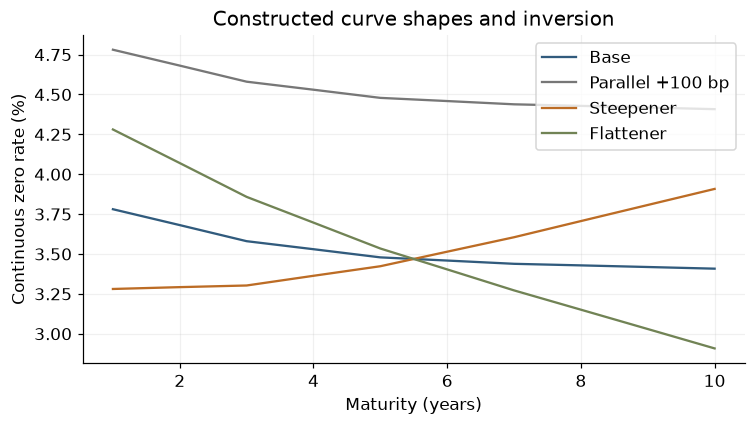

In [3]:
fig,ax=plt.subplots(figsize=(7,4))
for (name,values),color in zip(scenarios.items(),['#315b7d','#777777','#bc6c25','#718355']):
    ax.plot(years,100*values,label=name,color=color)
ax.set(xlabel='Maturity (years)',ylabel='Continuous zero rate (%)',title='Constructed curve shapes and inversion')
ax.legend();fig.tight_layout();plt.show()

## Interpretation

The parallel shock changes the level but leaves the term spread unchanged. Steepening and flattening change the spread by construction; none of these scenarios supplies recession evidence.